# Week 2 (starter): Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: !pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [11]:
# prompt = 'The capital of England is'   # TODO (you): your own short prompt
prompt = 'An example of a prompt that is long enough to be interesting, but not so long that it is boring is'
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [2025, 1672, 286, 257, 6152, 326, 318, 890, 1576, 284, 307, 3499, 11, 475, 407, 523, 890, 326, 340, 318, 14262, 318]
  pos 0: id   2025 -> 'An'
  pos 1: id   1672 -> ' example'
  pos 2: id    286 -> ' of'
  pos 3: id    257 -> ' a'
  pos 4: id   6152 -> ' prompt'
  pos 5: id    326 -> ' that'
  pos 6: id    318 -> ' is'
  pos 7: id    890 -> ' long'
  pos 8: id   1576 -> ' enough'
  pos 9: id    284 -> ' to'
  pos 10: id    307 -> ' be'
  pos 11: id   3499 -> ' interesting'
  pos 12: id     11 -> ','
  pos 13: id    475 -> ' but'
  pos 14: id    407 -> ' not'
  pos 15: id    523 -> ' so'
  pos 16: id    890 -> ' long'
  pos 17: id    326 -> ' that'
  pos 18: id    340 -> ' it'
  pos 19: id    318 -> ' is'
  pos 20: id  14262 -> ' boring'
  pos 21: id    318 -> ' is'

embedded prompt shape (seq_len, dim): (22, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'An'         0.168
  ' example'   0.049
  ' of'        0.019
  ' a'         0.018
  ' prompt'    0.044
  ' th

## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

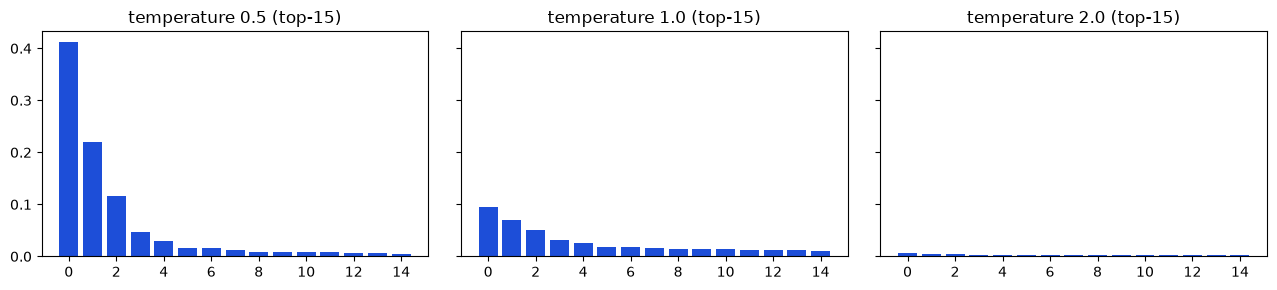

top token prob: temp 0.5 = 0.412, temp 1.0 = 0.095, temp 2.0 = 0.006


In [12]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

In [ ]:
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())
for t, tp in [(1e-6, 1.0), (0.7, 1.0), (1.3, 0.9)]:
    p = temperature(z, t)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')
# TODO (you): for each row, write what you predicted versus what you see.
# 1.) Near zero temperature; and 1.0 top-p: Expected this to blow up the differences betwween the probabilities, and decrease entropy, and entropy is low because the max probability 
# for the next token is so high as a result of the temperature induced explosion.
# 2.) Temperature 0.7 and top-p 1.0: Expected this to be a more balanced distribution, and it is, with a lower max probability and higher entropy than the first case. But with such a
# balanced distribution, and top-p=1.0, the nucleus sampling keeps the entire vocabulary, which I didn't expect.
# 3.) High temperature; <1.0 top-p: Even with a temperature over 1.0, I expected the nucleus to keep more tokens for this example after the second one, I'm surprised by the difference 
# top-p=0.9 makes, this might be explained by the vocabulary containing a very large relative number of low probability tokens which makes sense

temp 1e-06  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7    top-p 1.0: entropy 3.494, max prob 0.236, nucleus keeps 50258 tokens
temp 1.3    top-p 0.9: entropy 7.285, max prob 0.037, nucleus keeps 4882 tokens


## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

In [ ]:
# starter failure: near-zero temperature collapses to a single token
p0 = temperature(z, 1e-6)
print('temp -> 0: top token prob =', round(p0.max(), 6), '(greedy collapse)', '\n')

temps = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0]

params = [(x, 1.0) for x in temps]

# TODO (you): find your own surprising case (e.g. top-p = 1.0 keeps the whole vocab) and explain it.
# Top-p dominates the nucleus size in this case, top-p=1.0 essentially acts as no filter at all, so the nucleus sampling pattern swings from one extreme to the other,
# from keeping a single token to including the entire vocabulary, depending on a relatively salient boundary in the temperature parameter
# This is surprising because I expected the temperature to have a more consistent effect on the nucleus size
for t, tp in params:
    p = temperature(z, t)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')

print('\n')

params = [(x, 0.80) for x in temps]

for t, tp in params:
    p = temperature(z, t)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')

# When we move top-p below 1.0, the distribution of the nucleus size becomes somewhat more consistent, and the effect of temperature on the nucleus size is more predictable. 
# The mitigation is to use a real sub 1.0 threshold for top-p, that filters out the extremely low probability tokens
# I also notice the vocabulary size is 50257, and the nucleus size is being measured at 50258, so there could be floating-point rounding issues in the top-p calculation happening
# for the extremely low probability tokens

temp -> 0: top token prob = 1.0 (greedy collapse) 

temp 1e-06  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 1e-05  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.0001 top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.001  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.01   top-p 1.0: entropy 0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.1    top-p 1.0: entropy 0.183, max prob 0.957, nucleus keeps 7 tokens
temp 0.25   top-p 1.0: entropy 0.828, max prob 0.721, nucleus keeps 50258 tokens
temp 0.5    top-p 1.0: entropy 2.174, max prob 0.412, nucleus keeps 50258 tokens
temp 0.75   top-p 1.0: entropy 3.824, max prob 0.204, nucleus keeps 50258 tokens
temp 1.0    top-p 1.0: entropy 5.479, max prob 0.095, nucleus keeps 50258 tokens
temp 2.0    top-p 1.0: entropy 9.485, max prob 0.006, nucleus keeps 50220 tokens
temp 5.0    top-p 1.0: entropy 10.659, max prob 0.000, nucleus keeps 50258 to

## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).